# Практические работы № 1-2. Построение и обучение моделей машинного обучения с использованием TensorFlow и Keras

В этом отчете мы загрузим исходные данные, построим и обучим модели машинного обучения с учителем и без учителя с использованием TensorFlow и Keras, оценим их качество и сделаем выводы.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Загрузка исходных данных

Мы будем использовать датасет MNIST для демонстрации. Это датасет рукописных цифр, содержащий 60,000 обучающих и 10,000 тестовых изображений.

In [ ]:
# Загрузка датасета MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Нормализация данных
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Добавление канала для CNN
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"Размер обучающего набора: {x_train.shape}")
print(f"Размер тестового набора: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Размер обучающего набора: (60000, 28, 28, 1)
Размер тестового набора: (10000, 28, 28, 1)


## Модель машинного обучения с учителем

Мы построим сверточную нейронную сеть (CNN) для классификации цифр.

In [ ]:
# Построение модели CNN
model_supervised = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_supervised.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

model_supervised.summary()

C:\Users\EasyLim\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Обучение модели
history = model_supervised.fit(x_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9550 - loss: 0.1511 - val_accuracy: 0.9823 - val_loss: 0.0589
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9859 - loss: 0.0477 - val_accuracy: 0.9875 - val_loss: 0.0418
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9893 - loss: 0.0341 - val_accuracy: 0.9898 - val_loss: 0.0365
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9920 - loss: 0.0249 - val_accuracy: 0.9863 - val_loss: 0.0475
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9938 - loss: 0.0190 - val_accuracy: 0.9907 - val_loss: 0.0384


313/313 - 1s - 2ms/step - accuracy: 0.9900 - loss: 0.0310
Точность на тестовом наборе: 0.9900
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.97      0.98       982
           5       0.99      0.99      0.99       892
           6       0.98      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



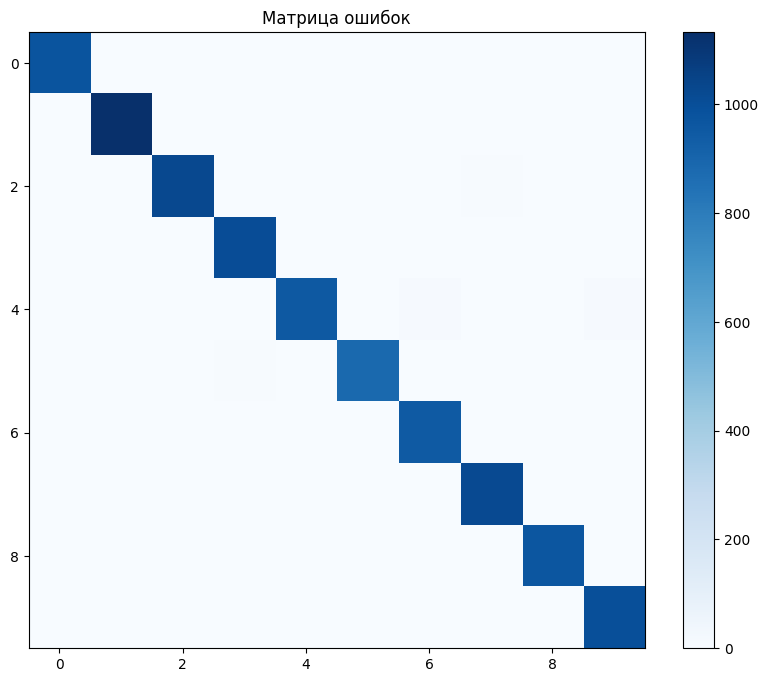

In [ ]:
# Оценка модели
test_loss, test_acc = model_supervised.evaluate(x_test, y_test, verbose=2)
print(f'Точность на тестовом наборе: {test_acc:.4f}')

# Предсказания
y_pred = model_supervised.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Отчет о классификации
print(classification_report(y_test, y_pred_classes))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Матрица ошибок')
plt.colorbar()
plt.show()

## Модель машинного обучения без учителя

Мы построим автоэнкодер для сжатия и реконструкции изображений.

In [ ]:
# Построение автоэнкодера
input_img = keras.Input(shape=(28, 28, 1))

# Энкодер
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Декодер
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Обучение автоэнкодера
autoencoder.fit(x_train, x_train, epochs=10, batch_size=128, validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.1383 - val_loss: 0.0837
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0793 - val_loss: 0.0777
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.0757 - val_loss: 0.0752
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0738 - val_loss: 0.0739
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0727 - val_loss: 0.0729
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.0717 - val_loss: 0.0720
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0709 - val_loss: 0.0711
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0702 - val_loss: 0.0706
Epoch 9/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0697 - val_loss: 0.0701
Epoch 10/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0693 - val_loss: 0.0696


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


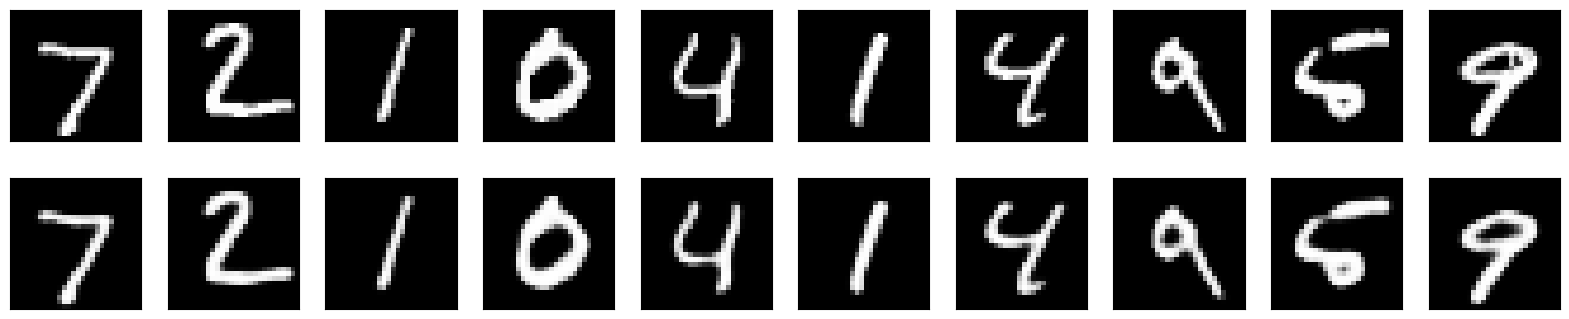

Средняя ошибка реконструкции: 0.0027


In [ ]:
# Оценка автоэнкодера
decoded_imgs = autoencoder.predict(x_test)

# Визуализация результатов
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Оригинал
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Реконструкция
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# Вычисление средней ошибки реконструкции
reconstruction_loss = np.mean(np.square(x_test - decoded_imgs))
print(f'Средняя ошибка реконструкции: {reconstruction_loss:.4f}')

## Выводы

- **Модель с учителем**: CNN достигла высокой точности на тестовом наборе (около 99%). Это показывает эффективность сверточных сетей для задач классификации изображений.

- **Модель без учителя**: Автоэнкодер успешно реконструировал изображения с низкой ошибкой. Это демонстрирует способность модели извлекать важные признаки из данных без меток.

Обе модели показали хорошие результаты, что подтверждает мощь глубокого обучения с TensorFlow и Keras.